<img src="http://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br>

# Python for Financial Data Science &mdash; Viz Basics

Dr Yves J Hilpisch

<a href='mailto:team@tpq.io'>team@tpq.io</a> | <a href='http://tpq.io'>http://tpq.io</a>

The Python Quants GmbH

In [1]:
import pandas as pd
import warnings
warnings.simplefilter('ignore')

## Example Data Retrieval

Retrieval and visualization of financial data.

In [2]:
data = pd.read_csv('http://hilpisch.com/tr_eikon_eod_data.csv',
                  index_col=0, parse_dates=True).dropna()

In [3]:
AAPL = pd.DataFrame(data['AAPL.O'])
AAPL.columns = ['Close']

In [4]:
AAPL.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2138 entries, 2010-01-04 to 2018-06-29
Data columns (total 1 columns):
Close    2138 non-null float64
dtypes: float64(1)
memory usage: 33.4 KB


In [5]:
AAPL.tail()

,Close
Date,
2018-06-25,182.17
2018-06-26,184.43
2018-06-27,184.16
2018-06-28,185.50
2018-06-29,185.11


## Basic matplotlib plotting

In [6]:
%matplotlib inline

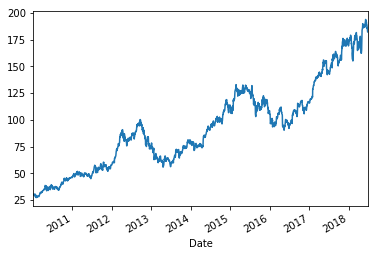

In [7]:
AAPL['Close'].plot()

In [8]:
import numpy as np
log_rets = np.log(AAPL['Close'] / AAPL['Close'].shift(1))

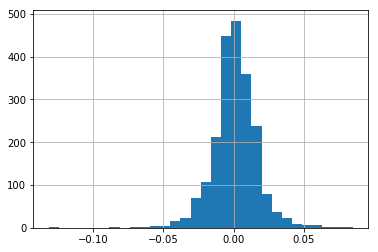

In [9]:
log_rets.hist(bins=30)

In [10]:
import matplotlib.pyplot as plt

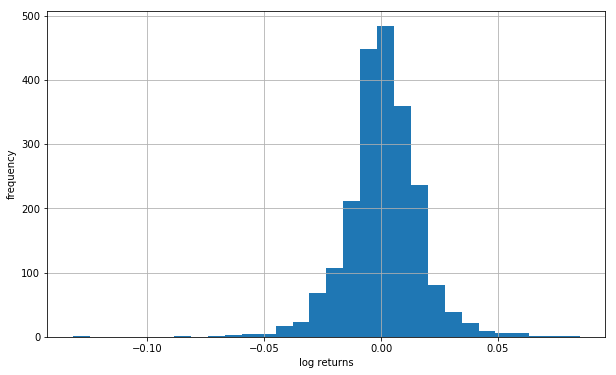

In [11]:
log_rets.hist(figsize=(10, 6), bins=30)
plt.xlabel('log returns')
plt.ylabel('frequency')

### seaborn for Statistical Plotting

In [12]:
import seaborn as sns
sns.set()

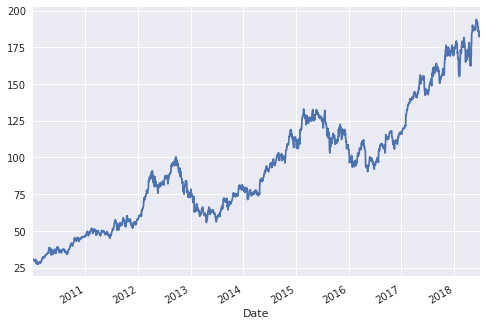

In [13]:
AAPL['Close'].plot()

In [14]:
# 42 & 252 days trends (moving averages)
AAPL['42d'] = AAPL['Close'].rolling(42).mean()
AAPL['252d'] = AAPL['Close'].rolling(252).mean()

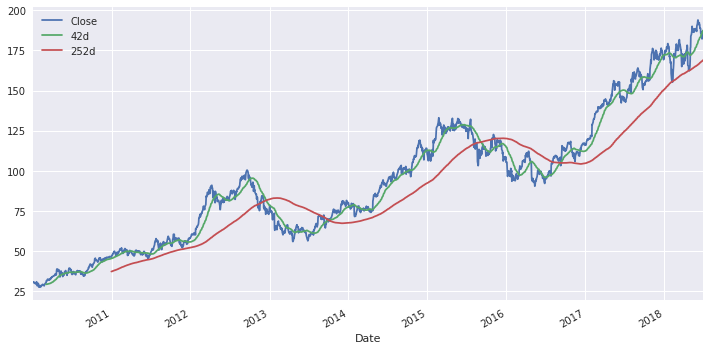

In [15]:
AAPL[['Close', '42d', '252d']].plot(figsize=(12, 6));

In [16]:
MSFT = pd.DataFrame(data['MSFT.O'])
MSFT.columns = ['Close']

In [17]:
data = pd.DataFrame({'AAPL': AAPL['Close'], 'MSFT': MSFT['Close']})
data.tail() 

,AAPL,MSFT
Date,,
2018-06-25,182.17,98.39
2018-06-26,184.43,99.08
2018-06-27,184.16,97.54
2018-06-28,185.50,98.63
2018-06-29,185.11,98.61


In [18]:
import numpy as np
rets = np.log(data / data.shift(1))
rets.tail()

,AAPL,MSFT
Date,,
2018-06-25,-0.014983,-0.020323
2018-06-26,0.012330,0.006988
2018-06-27,-0.001465,-0.015665
2018-06-28,0.007250,0.011113
2018-06-29,-0.002105,-0.000203


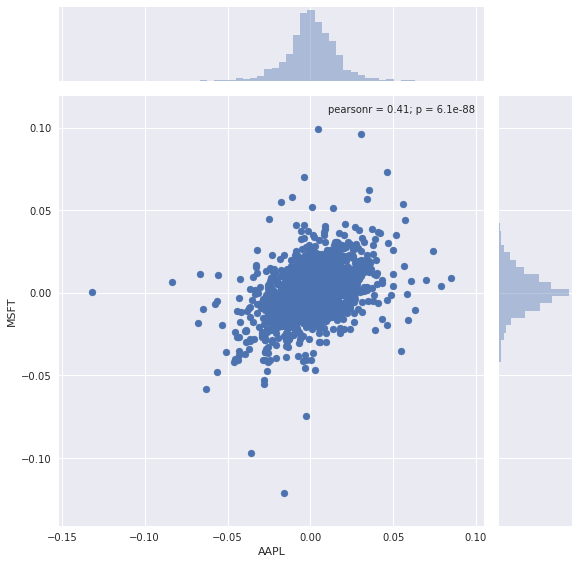

In [19]:
sns.jointplot(rets['AAPL'], rets['MSFT'], size=8);

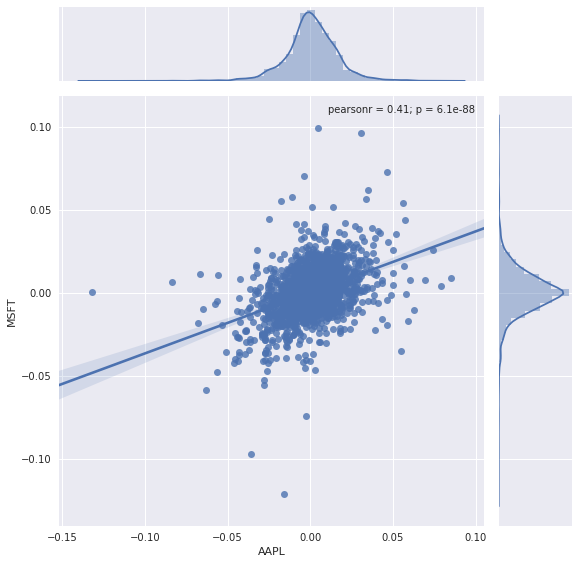

In [20]:
sns.jointplot(rets['AAPL'], rets['MSFT'], size=8, kind='reg');

<img src="http://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br>

<a href="http://tpq.io" target="_blank">http://tpq.io</a> | <a href="http://twitter.com/dyjh" target="_blank">@dyjh</a> | <a href="mailto:team@tpq.io">team@tpq.io</a>

**Python Training** |
<a href="http://training.tpq.io">http://training.tpq.io</a>

**Python for Finance** |
<a href="http://shop.oreilly.com/product/0636920032441.do" target="_blank">Python for Finance @ O'Reilly</a>

**Derivatives Analytics with Python** |
<a href="http://eu.wiley.com/WileyCDA/WileyTitle/productCd-1119037999.html" target="_blank">Derivatives Analytics @ Wiley Finance</a>